# Convolutional Neural Networks
Nesse notebook, vamos implementar uma CNN (Convolutional Neural Network) para classificação de imagens, de forma a identificar e classificar as classes dentro do dataset [CIFAR10](https://www.cs.toronto.edu/~kriz/cifar.html). Além do treino e validação de híper-parâmetros, eu vou mostrar como algumas imagens são transformadas pela rede

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
import base64
import itertools
import copy

from torchvision.datasets import ImageFolder

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import random_split, DataLoader
import tqdm

import sys
from pathlib import Path

root = Path().resolve().parent  # aponta para machine-learning/
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from classes.cnn import CNN

Importando o dataset

In [6]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

DATA_FOLDER = "../data"

batch_size = 2048

transform_train = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

try:
    print("Tentando baixar CIFAR-10...")

    train_set = torchvision.datasets.CIFAR10(
        root=DATA_FOLDER,
        train=True,
        download=True,
        transform=transform_train,
    )

    test_set = torchvision.datasets.CIFAR10(
        root=DATA_FOLDER,
        train=False,
        download=True,
        transform=transform_test
    )

    

except Exception as e:
    print("Falhou o download, usando dataset local...")
    print(e)

    train_set = ImageFolder(
        root=f"{DATA_FOLDER}/cifar10/train",
        transform=transform_train
    )

    test_set = ImageFolder(
        root=f"{DATA_FOLDER}/cifar10/test",
        transform=transform_test
    )

    classes = train_set.classes  # pega automaticamente os nomes

# DataLoaders
train_loader = DataLoader(
    train_set,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_set,
    batch_size=batch_size,
    shuffle=False,  # melhor prática
    num_workers=2
)

cuda:0
Tentando baixar CIFAR-10...
Files already downloaded and verified


c:\Users\Jotinha\Documents\Github\machine-learning\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified


In [7]:
cnn = CNN().to(device)
criterion = nn.CrossEntropyLoss()

BATCH_SIZES    = [256, 1024]
LEARNING_RATES = [1e-2, 1e-3, 5e-4]
MAX_EPOCHS     = 40
PATIENCE       = 5          # early stopping
VAL_FRACTION   = 0.1


n_val   = int(len(train_set) * VAL_FRACTION)
n_train = len(train_set) - n_val
train_sub, val_sub = random_split(
    train_set, [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)

def make_loaders(bs):
    tr = DataLoader(train_sub, batch_size=bs, shuffle=True,  num_workers=2, pin_memory=True)
    vl = DataLoader(val_sub,   batch_size=512, shuffle=False, num_workers=2, pin_memory=True)
    return tr, vl
 
@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader):
    """Avalia o modelo no conjunto de dados fornecido pelo loader, retornando a perda média e a acurácia.

    Args:
        model (nn.Module): O modelo a ser avaliado.
        loader (DataLoader): O carregador de dados.

    Returns:
        tuple: Uma tupla contendo a perda média e a acurácia.
    """
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    crit = nn.CrossEntropyLoss()
    for xb, tb in loader:
        xb, tb = xb.to(device), tb.to(device)
        out = model(xb)
        total_loss += crit(out, tb).item()
        correct    += (out.argmax(1) == tb).sum().item()
        n          += tb.size(0)
    return total_loss / len(loader), correct / n

Fazendo o treino e a validação

In [8]:
gs_results = {}   # chave: (batch_size, lr)
 
for bs, lr in itertools.product(BATCH_SIZES, LEARNING_RATES):
    print(f"\n{'='*50}\nbatch={bs}  lr={lr}\n{'='*50}")
    tr_loader, vl_loader = make_loaders(bs)
 
    model     = CNN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=2
    )
 
    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    best_val, best_state, no_impr = float('inf'), None, 0
 
    for epoch in range(MAX_EPOCHS):
        # — treino —
        model.train()
        running = 0.0
        for xb, tb in tr_loader:
            xb, tb = xb.to(device), tb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), tb)
            loss.backward()
            optimizer.step()
            running += loss.item()
        train_loss = running / len(tr_loader)
 
        # — validação —
        val_loss, val_acc = evaluate(model, vl_loader)
        scheduler.step(val_loss)
 
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
 
        print(f"  ep {epoch+1:>3}  train={train_loss:.4f}  val={val_loss:.4f}  acc={val_acc:.3f}  lr={optimizer.param_groups[0]['lr']:.1e}")
 
        # — early stopping —
        if val_loss < best_val - 1e-4:
            best_val, best_state, no_impr = val_loss, copy.deepcopy(model.state_dict()), 0
        else:
            no_impr += 1
            if no_impr >= PATIENCE:
                print(f"  ↳ early stopping na época {epoch+1}")
                break
 
    model.load_state_dict(best_state)
    gs_results[(bs, lr)] = {"model": model, "history": history, "best_val": best_val}


batch=256  lr=0.01
  ep   1  train=1.9727  val=1.7936  acc=0.320  lr=1.0e-02
  ep   2  train=1.6814  val=1.5956  acc=0.413  lr=1.0e-02
  ep   3  train=1.5094  val=1.4935  acc=0.470  lr=1.0e-02
  ep   4  train=1.3914  val=1.4056  acc=0.493  lr=1.0e-02
  ep   5  train=1.3197  val=1.3350  acc=0.521  lr=1.0e-02
  ep   6  train=1.2562  val=1.3013  acc=0.543  lr=1.0e-02
  ep   7  train=1.2121  val=1.2897  acc=0.543  lr=1.0e-02
  ep   8  train=1.1708  val=1.3385  acc=0.541  lr=1.0e-02
  ep   9  train=1.1447  val=1.2453  acc=0.572  lr=1.0e-02
  ep  10  train=1.1034  val=1.2659  acc=0.562  lr=1.0e-02
  ep  11  train=1.0724  val=1.2137  acc=0.580  lr=1.0e-02
  ep  12  train=1.0433  val=1.2437  acc=0.580  lr=1.0e-02
  ep  13  train=1.0087  val=1.2580  acc=0.567  lr=1.0e-02
  ep  14  train=1.0098  val=1.2323  acc=0.576  lr=5.0e-03
  ep  15  train=0.8854  val=1.2161  acc=0.595  lr=5.0e-03
  ep  16  train=0.8519  val=1.2482  acc=0.588  lr=5.0e-03
  ↳ early stopping na época 16

batch=256  lr=0.001


Agora pegando os melhores híperparâmetros

In [9]:
ranking = sorted(gs_results.items(), key=lambda kv: kv[1]["best_val"])
print("\nRANKING:")
for (bs, lr), info in ranking:
    print(f"  batch={bs}  lr={lr:.0e}  →  val_loss={info['best_val']:.4f}")
 
best_key = ranking[0][0]
cnn      = gs_results[best_key]["model"]   # melhor modelo, disponível como `cnn`
print(f"\n→ Melhor: batch={best_key[0]}, lr={best_key[1]:.0e}")


RANKING:
  batch=256  lr=1e-03  →  val_loss=1.1097
  batch=256  lr=5e-04  →  val_loss=1.1198
  batch=1024  lr=1e-03  →  val_loss=1.1253
  batch=1024  lr=5e-04  →  val_loss=1.1527
  batch=1024  lr=1e-02  →  val_loss=1.2127
  batch=256  lr=1e-02  →  val_loss=1.2137

→ Melhor: batch=256, lr=1e-03


Plotando o erros dentro de cada conjunto de híperparâmetros, mostrando a acurácia na validação, a loss dentro do conjunto de treino e de validação

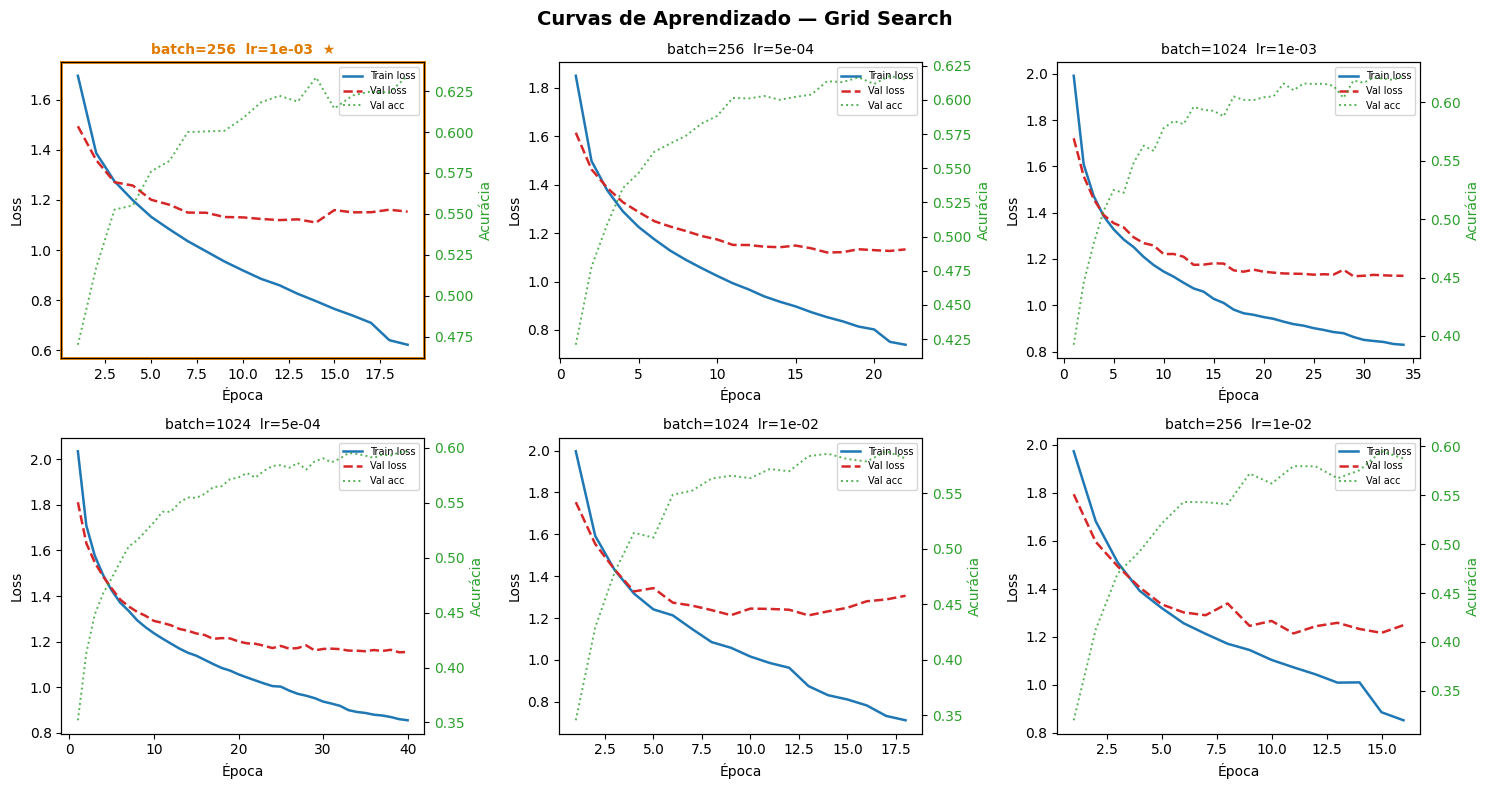

In [ ]:
n_cfg = len(gs_results)
cols  = 3
rows  = (n_cfg + cols - 1) // cols
 
fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
axes = np.array(axes).flatten()
 
for idx, ((bs, lr), info) in enumerate(ranking):   # ranking já ordenado
    ax   = axes[idx]
    hist = info["history"]
    ep   = range(1, len(hist["train_loss"]) + 1)
    ax2  = ax.twinx()
 
    ax.plot(ep, hist["train_loss"], color="#1f77b4", lw=1.8, label="Train loss")
    ax.plot(ep, hist["val_loss"],   color="#d62728", lw=1.8, ls="--", label="Val loss")
    ax2.plot(ep, hist["val_acc"],   color="#2ca02c", lw=1.4, ls=":",  label="Val acc", alpha=0.8)
 
    is_best = (bs, lr) == best_key
    ax.set_title(
        f"batch={bs}  lr={lr:.0e}" + ("  ★" if is_best else ""),
        fontweight="bold" if is_best else "normal",
        color="#e07b00" if is_best else "black", fontsize=10
    )
    ax.set_xlabel("Época"); ax.set_ylabel("Loss")
    ax2.set_ylabel("Acurácia", color="#2ca02c")
    ax2.tick_params(axis='y', labelcolor="#2ca02c")
    lines = ax.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
    lbls  = ax.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
    ax.legend(lines, lbls, fontsize=7, loc="upper right")
    if is_best:
        for sp in ax.spines.values(): sp.set_edgecolor("#e07b00"); sp.set_linewidth(2)
 
for ax in axes[n_cfg:]: ax.set_visible(False)
 
fig.suptitle("Curvas de Aprendizado — Grid Search", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

Agora vou retreinar com os melhores híperparâmetros e unindo os conjuntos de treino e validação

In [11]:
best_bs, best_lr = best_key

full_loader = DataLoader(
    train_set,
    batch_size=best_bs,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

cnn       = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn.parameters(), lr=best_lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

# Usa o número de épocas que o melhor experimento rodou (já com early stopping)
best_n_epochs = len(gs_results[best_key]["history"]["train_loss"])
print(f"Retreinando com batch={best_bs}, lr={best_lr:.0e}, épocas={best_n_epochs}")

for epoch in range(best_n_epochs):
    cnn.train()
    running = 0.0
    for xb, tb in full_loader:
        xb, tb = xb.to(device), tb.to(device)
        optimizer.zero_grad()
        loss = criterion(cnn(xb), tb)
        loss.backward()
        optimizer.step()
        running += loss.item()
    train_loss = running / len(full_loader)
    scheduler.step(train_loss)
    print(f"  ep {epoch+1:>3}  train={train_loss:.4f}  lr={optimizer.param_groups[0]['lr']:.1e}")

print("✓ Retreino concluído.")

Retreinando com batch=256, lr=1e-03, épocas=19
  ep   1  train=1.7708  lr=1.0e-03
  ep   2  train=1.3797  lr=1.0e-03
  ep   3  train=1.2521  lr=1.0e-03
  ep   4  train=1.1706  lr=1.0e-03
  ep   5  train=1.1072  lr=1.0e-03
  ep   6  train=1.0575  lr=1.0e-03
  ep   7  train=1.0054  lr=1.0e-03
  ep   8  train=0.9612  lr=1.0e-03
  ep   9  train=0.9234  lr=1.0e-03
  ep  10  train=0.8846  lr=1.0e-03
  ep  11  train=0.8553  lr=1.0e-03
  ep  12  train=0.8229  lr=1.0e-03
  ep  13  train=0.7979  lr=1.0e-03
  ep  14  train=0.7633  lr=1.0e-03
  ep  15  train=0.7354  lr=1.0e-03
  ep  16  train=0.7103  lr=1.0e-03
  ep  17  train=0.6887  lr=1.0e-03
  ep  18  train=0.6614  lr=1.0e-03
  ep  19  train=0.6295  lr=1.0e-03
✓ Retreino concluído.


Aplicando a predição por batch:

In [12]:
for x_batch, t_batch in test_loader:
    x_batch, t_batch = x_batch.to(device), t_batch.to(device)
    y_batch = cnn.forward(x_batch)
    predicted = torch.argmax(y_batch, dim=1)
    accuracy = (predicted == t_batch).float().mean()
    print(f"Test Accuracy: {accuracy.item():.4f}")

Test Accuracy: 0.6157
Test Accuracy: 0.6235
Test Accuracy: 0.6133
Test Accuracy: 0.6323
Test Accuracy: 0.6045


Agora vou pegar algumas imagens dentro do conjunto e mostrar como elas são transformadas dentro da rede e mostrar essas transformações

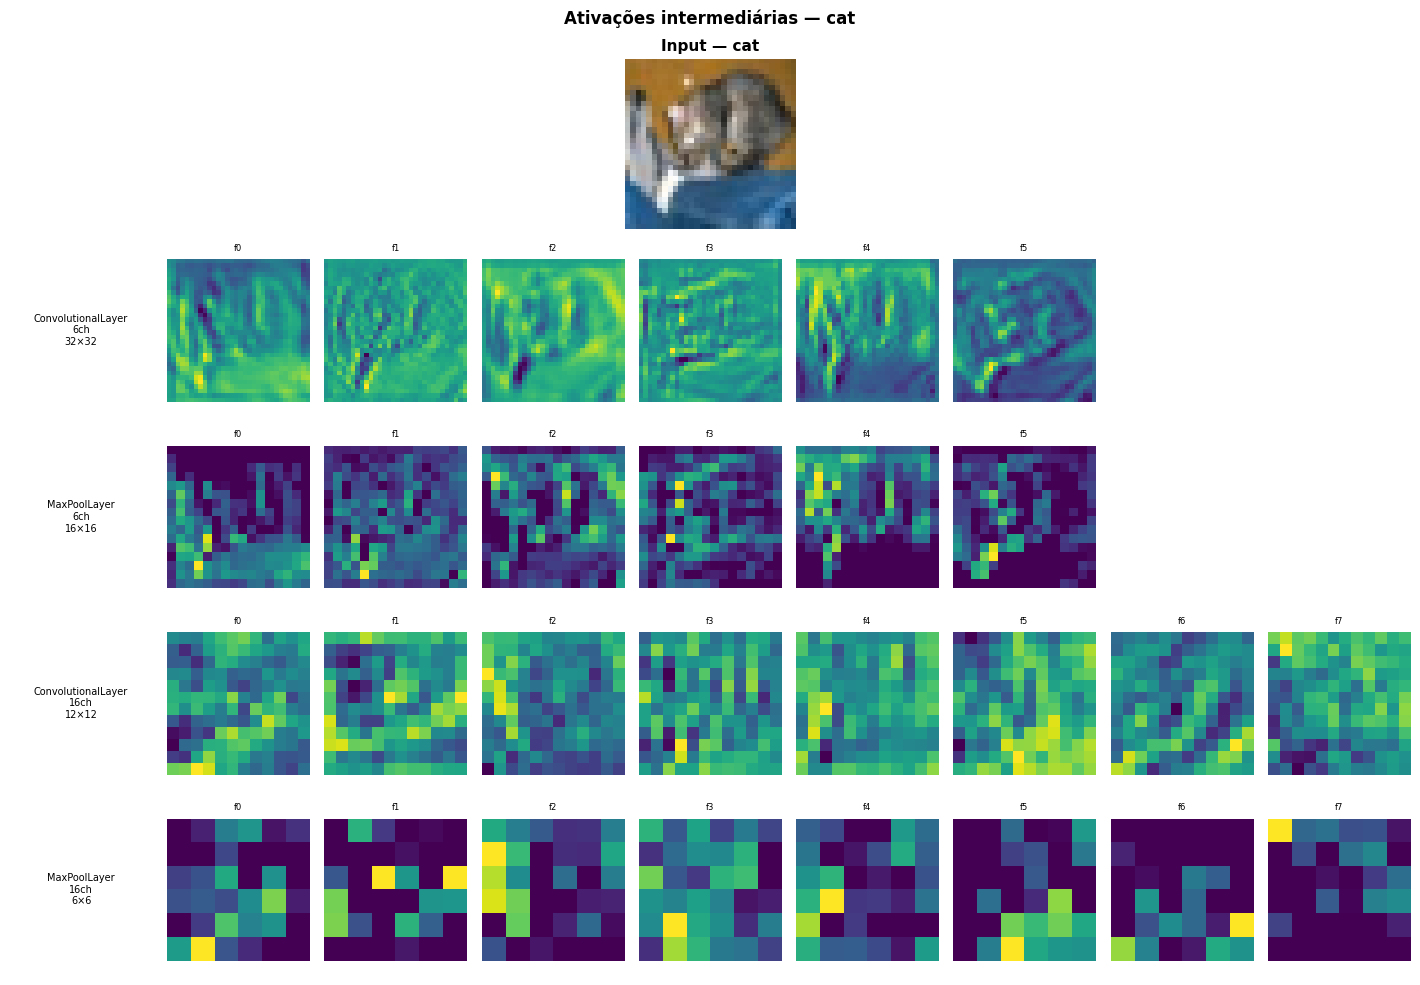

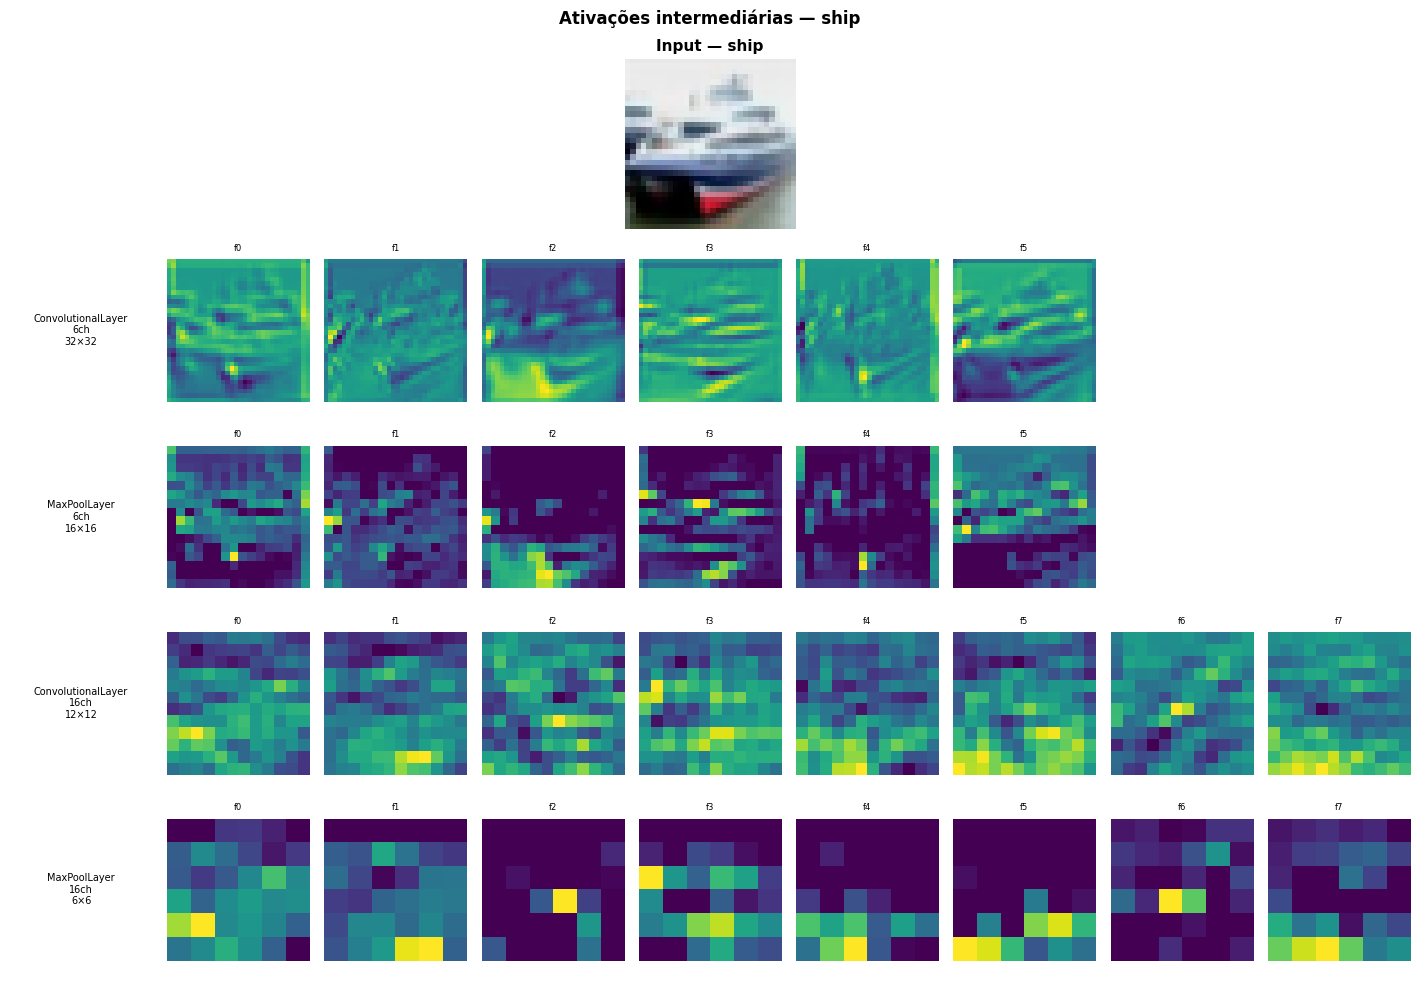

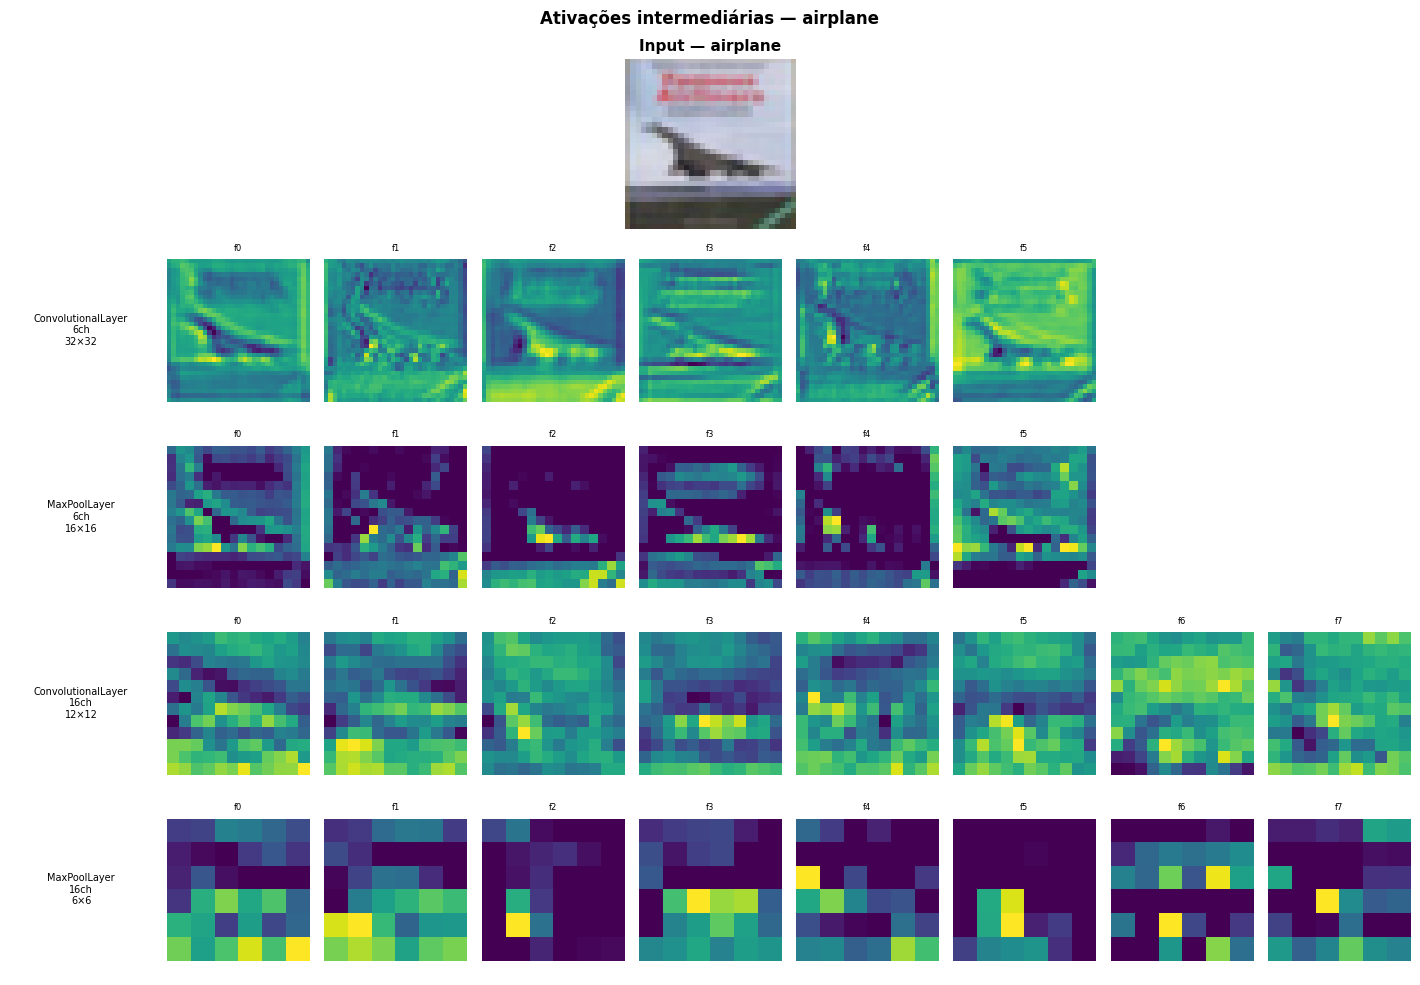

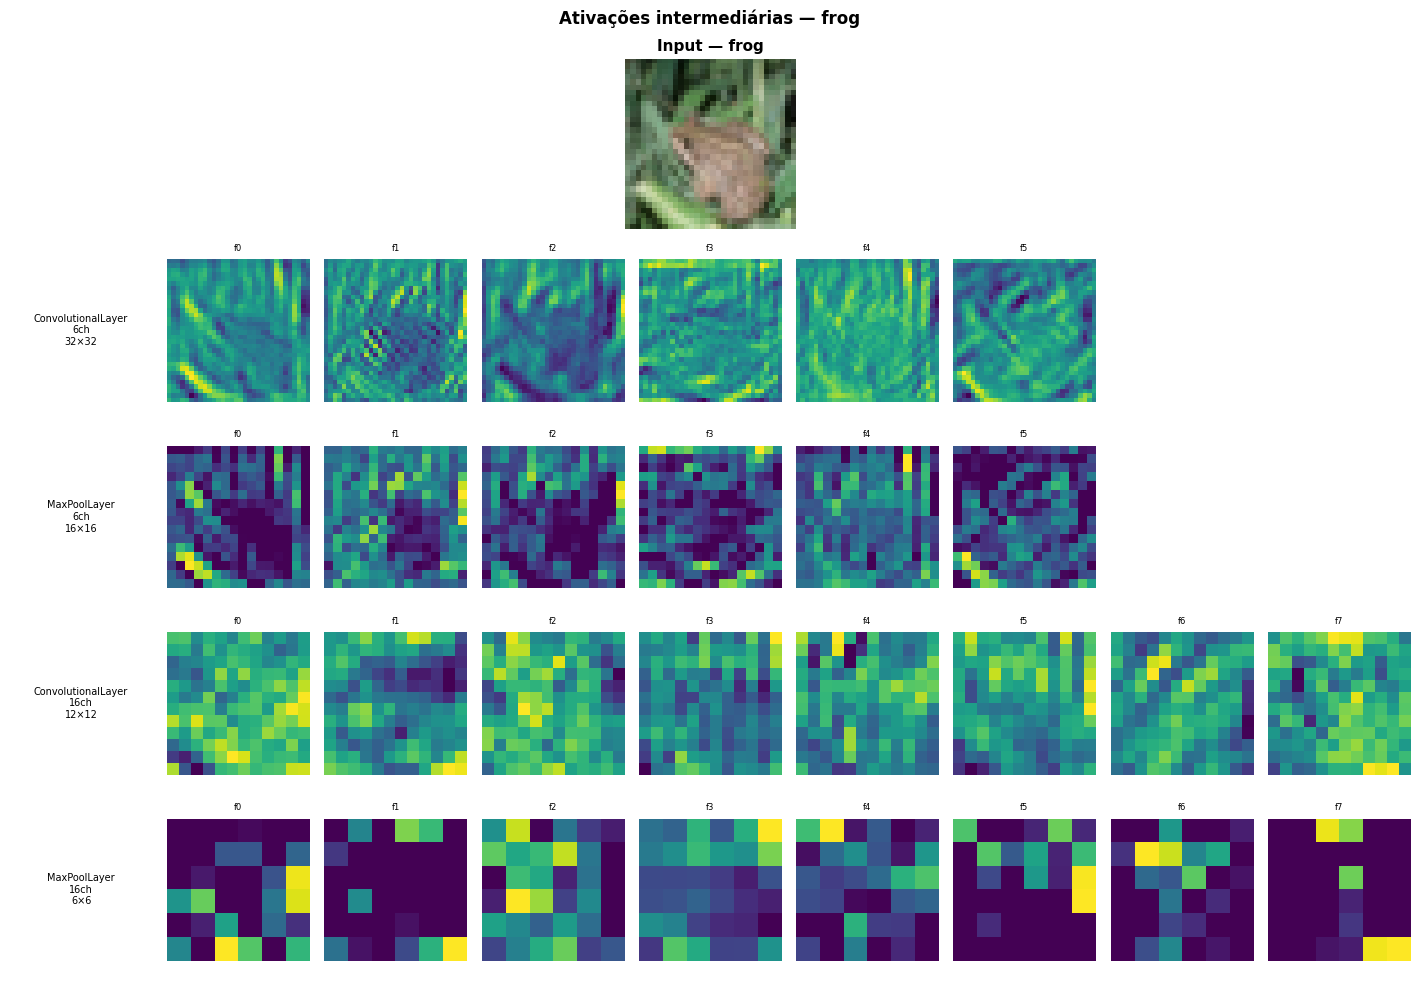

In [14]:
CIFAR10_CLASSES = ["airplane","automobile","bird","cat","deer",
                   "dog","frog","horse","ship","truck"]
 
# Pega 1 imagem de cada classe (até 4)
N_SAMPLES  = 4
N_FILTERS  = 8   # quantos feature maps mostrar por camada
samples    = []
seen       = set()
for img, lbl in test_set:
    if lbl not in seen:
        samples.append((img, lbl))
        seen.add(lbl)
    if len(samples) >= N_SAMPLES:
        break
 
cnn.eval()
for img_tensor, label in samples:
    x = img_tensor.unsqueeze(0).to(device)
 
    # coleta ativações
    activations, out = [], x
    for layer in cnn.layers:
        out = layer.forward(out)
        activations.append((type(layer).__name__, out.detach().cpu()))
 
    spatial = [(n, a) for n, a in activations
               if a.dim() == 4 and n in ("ConvolutionalLayer", "MaxPoolLayer")]
 
    n_rows = len(spatial) + 1
    fig, axes_grid = plt.subplots(n_rows, N_FILTERS + 1,
                                  figsize=(N_FILTERS * 1.6 + 1.5, n_rows * 2))
 
    # imagem original
    img_np = img_tensor.permute(1, 2, 0).numpy() * 0.5 + 0.5   # desnormaliza (mean=0.5,std=0.5)
    img_np = np.clip(img_np, 0, 1)
    for ax in axes_grid[0]: ax.set_visible(False)
    ax0 = fig.add_subplot(n_rows, 1, 1)   # ocupa linha inteira
    ax0.imshow(img_np); ax0.axis("off")
    ax0.set_title(f"Input — {CIFAR10_CLASSES[label]}", fontsize=11, fontweight="bold")
    # remove a primeira linha de subplots (substituída por ax0)
    for ax in axes_grid[0]: ax.remove()
 
    # feature maps
    for row, (lname, act) in enumerate(spatial, start=1):
        n_ch  = act.shape[1]
        shown = min(N_FILTERS, n_ch)
        # coluna 0: rótulo
        axes_grid[row][0].text(0.5, 0.5,
            f"{lname}\n{n_ch}ch\n{act.shape[2]}×{act.shape[3]}",
            ha="center", va="center", fontsize=7, transform=axes_grid[row][0].transAxes)
        axes_grid[row][0].axis("off")
        for col in range(shown):
            axes_grid[row][col + 1].imshow(act[0, col].numpy(), cmap="viridis")
            axes_grid[row][col + 1].set_title(f"f{col}", fontsize=6)
            axes_grid[row][col + 1].axis("off")
        for col in range(shown, N_FILTERS):
            axes_grid[row][col + 1].set_visible(False)
 
    fig.suptitle(f"Ativações intermediárias — {CIFAR10_CLASSES[label]}",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()